In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\X_train.csv")
X_test = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\X_test.csv")

y_train = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\y_train.csv").squeeze()
y_test = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\y_test.csv").squeeze()

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [4]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [5]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

In [6]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9995065731505305
Precision: 0.971830985915493
Recall   : 0.7263157894736842
F1 Score : 0.8313253012048193
ROC AUC  : 0.9239442050077622


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



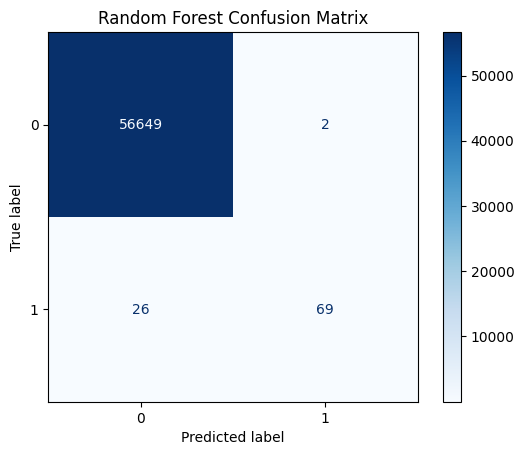

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [9]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
17     V17    0.156591
14     V14    0.135281
12     V12    0.130206
10     V10    0.087799
16     V16    0.072675
11     V11    0.050980
9       V9    0.033680
18     V18    0.031980
4       V4    0.025802
7       V7    0.024569


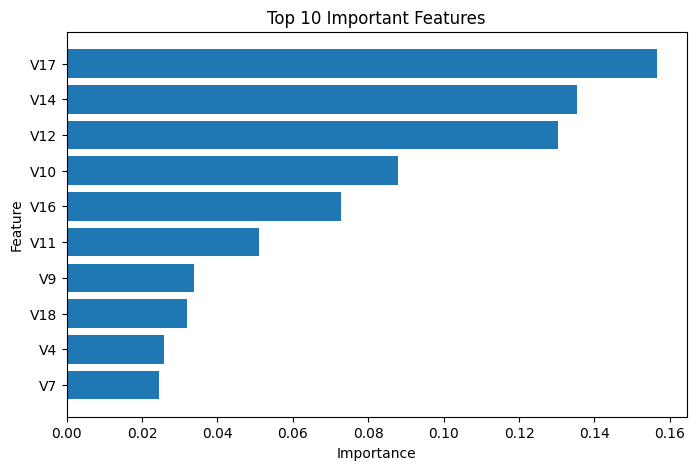

In [10]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [12]:
joblib.dump(
    rf_model,
    "C:\\Users\\vipul\\Desktop\\Fraud_Detection\\ml\\models\\random_forest.pkl"
)

print("Random Forest Model Saved Successfully")

Random Forest Model Saved Successfully
